# Titanic Dataset — Data Cleaning & Exploratory Data Analysis

This notebook performs data cleaning and exploratory data analysis (EDA) on the Kaggle Titanic
`train.csv` dataset. It covers:

1. **Data Cleaning** — loading, missing-value inspection, imputation, and feature engineering
2. **Exploratory Data Analysis** — survival patterns across sex, class, age, fare, and family size
3. **Insights** — a written summary of key findings backed by numbers from the analysis

All charts are saved to the `outputs/` folder and use a consistent color palette throughout.

## 0. Setup

Import libraries and configure a consistent visual style / color palette for all charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create outputs folder for saved charts
os.makedirs('outputs', exist_ok=True)

# Consistent color palette used throughout the notebook
PALETTE = {"main": "#2E86AB", "accent": "#E63946", "neutral": "#8D99AE",
           "pos": "#2A9D8F", "neg": "#E76F51"}
SURV_PAL = {0: PALETTE["neg"], 1: PALETTE["pos"]}   # Died = red-orange, Survived = teal

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100


## 1. Data Cleaning

### 1.1 Load data and inspect shape, dtypes, and missing values

In [2]:
df = pd.read_csv('train.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
print("Data types:")
print(df.dtypes)


Shape: 891 rows x 12 columns

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [3]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Observations:** `Cabin` is missing for 687 of 891 passengers (~77.1%), `Age` is missing for 177 passengers (~19.87%), and `Embarked` is missing for only 2 passengers.

### 1.2 Impute `Age` (median grouped by Pclass & Sex) and `Embarked` (mode)

In [4]:
# Age: impute using the median Age within each Pclass/Sex combination
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: impute with the mode (most frequent port)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print(f"Embarked mode used for imputation: '{embarked_mode}'")
print(f"Remaining missing Age values: {df['Age'].isnull().sum()}")
print(f"Remaining missing Embarked values: {df['Embarked'].isnull().sum()}")


Embarked mode used for imputation: 'S'
Remaining missing Age values: 0
Remaining missing Embarked values: 0


### 1.3 Feature engineering: `Has_Cabin`, `Title`, `FamilySize`

In [5]:
# Has_Cabin: 1 if a cabin was recorded, 0 otherwise
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

# Title: extracted from the Name field, grouped into Mr / Mrs / Miss / Master / Rare
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    mapping = {
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
    }
    if title in ['Mr', 'Mrs', 'Miss', 'Master']:
        return title
    return mapping.get(title, 'Rare')

df['Title'] = df['Name'].apply(extract_title)

# FamilySize: siblings/spouses + parents/children + self
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['Name', 'Title', 'Has_Cabin', 'SibSp', 'Parch', 'FamilySize']].head()


,Name,Title,Has_Cabin,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",Mr,0,1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,1,1,0,2
2,"Heikkinen, Miss. Laina",Miss,0,0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,1,0,2
4,"Allen, Mr. William Henry",Mr,0,0,0,1


**Cleaning summary:** After imputation there are zero missing values in `Age` and `Embarked`. `Cabin` is left as-is (its absence is captured by `Has_Cabin`). Title extraction yields 517 'Mr', 185 'Miss', 126 'Mrs', 40 'Master', and 23 'Rare' titles.

## 2. Exploratory Data Analysis

### 2.1 Overall survival rate

Overall survival rate: 38.38%


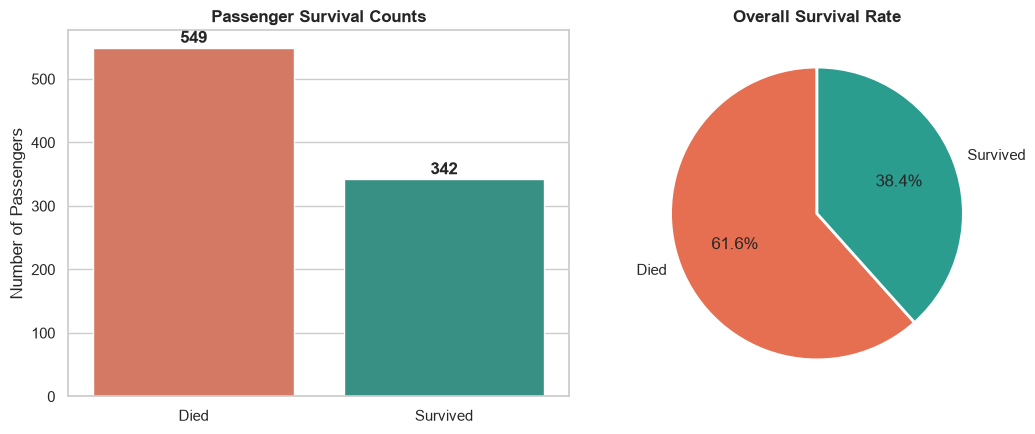

In [6]:
counts = df['Survived'].value_counts().sort_index()
overall_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {overall_rate:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(x=['Died', 'Survived'], y=counts.values, hue=['Died', 'Survived'],
            palette=[PALETTE["neg"], PALETTE["pos"]], legend=False, ax=axes[0])
axes[0].set_title('Passenger Survival Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Died', 'Survived'], autopct='%1.1f%%',
            colors=[PALETTE["neg"], PALETTE["pos"]], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Overall Survival Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/01_overall_survival.png', bbox_inches='tight')
plt.show()


### 2.2 Survival rate by Sex

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


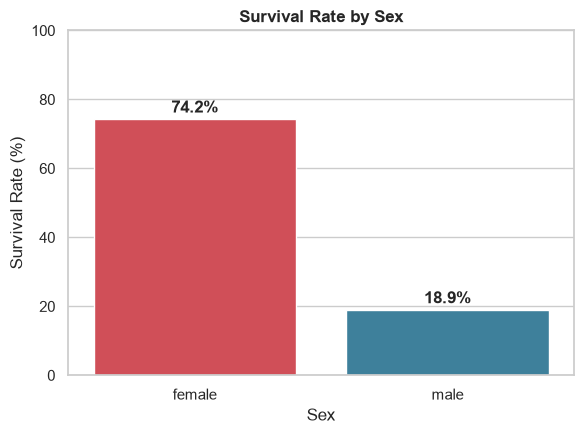

In [7]:
sex_surv = df.groupby('Sex')['Survived'].mean() * 100
print(sex_surv.round(2))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(x=sex_surv.index, y=sex_surv.values, hue=sex_surv.index,
            palette=[PALETTE["accent"], PALETTE["main"]], legend=False, ax=ax)
ax.set_title('Survival Rate by Sex', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Sex')
ax.set_ylim(0, 100)
for i, v in enumerate(sex_surv.values):
    ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_survival_by_sex.png', bbox_inches='tight')
plt.show()


### 2.3 Survival rate by Pclass

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


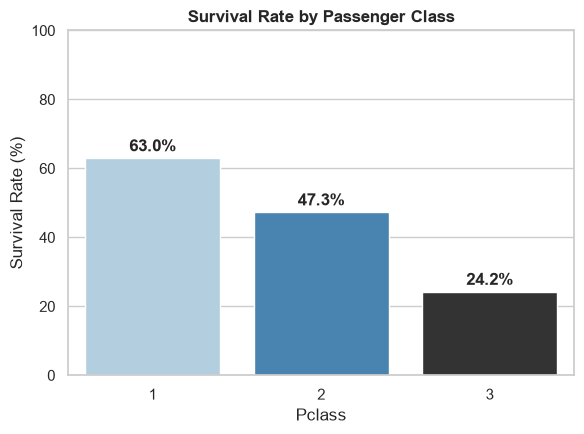

In [8]:
pclass_surv = df.groupby('Pclass')['Survived'].mean() * 100
print(pclass_surv.round(2))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(x=pclass_surv.index, y=pclass_surv.values, hue=pclass_surv.index,
            palette='Blues_d', legend=False, ax=ax)
ax.set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Pclass')
ax.set_ylim(0, 100)
for i, v in enumerate(pclass_surv.values):
    ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/03_survival_by_pclass.png', bbox_inches='tight')
plt.show()


### 2.4 Age distribution split by Survived

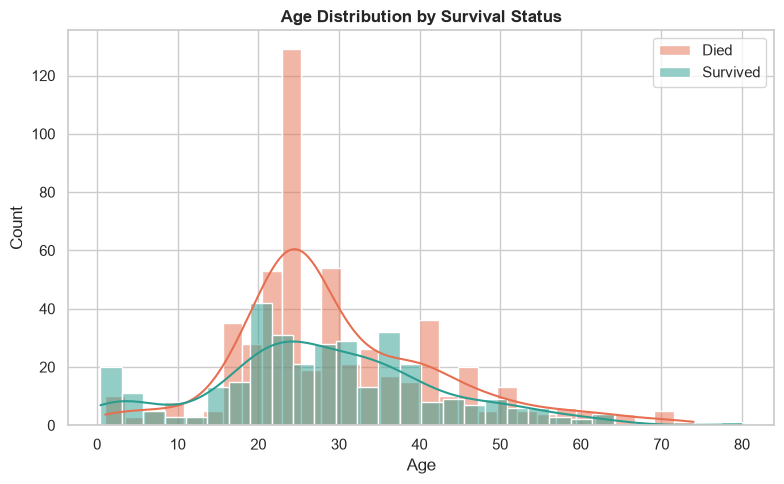

Median age (survived): 27.0
Median age (died):     25.0


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df[df['Survived'] == 0]['Age'], color=PALETTE["neg"], label='Died',
             kde=True, alpha=0.5, bins=30, ax=ax)
sns.histplot(df[df['Survived'] == 1]['Age'], color=PALETTE["pos"], label='Survived',
             kde=True, alpha=0.5, bins=30, ax=ax)
ax.set_title('Age Distribution by Survival Status', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/04_age_distribution.png', bbox_inches='tight')
plt.show()

print(f"Median age (survived): {df[df.Survived==1].Age.median()}")
print(f"Median age (died):     {df[df.Survived==0].Age.median()}")


### 2.5 Fare distribution and boxplot vs Survived

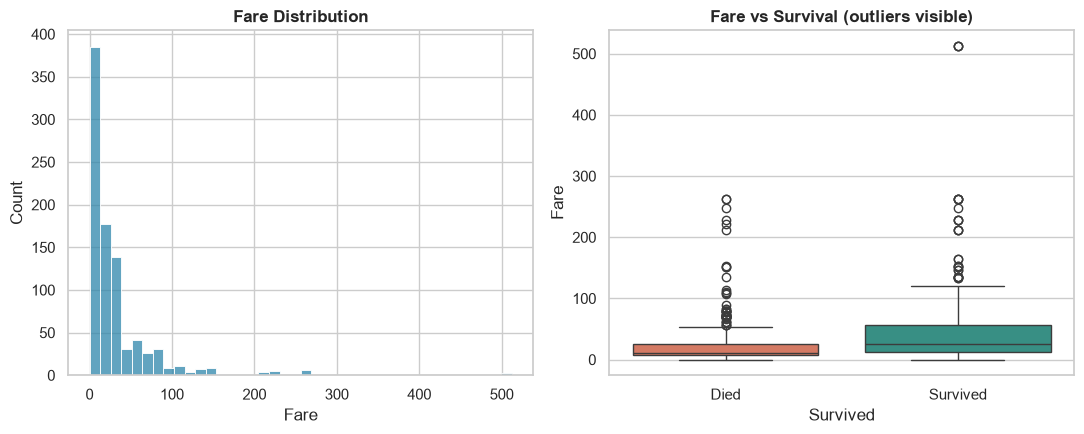

Fare IQR upper fence: 65.63 | Outliers above fence: 116
Median fare (survived): 26.00
Median fare (died):     10.50


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(df['Fare'], bins=40, color=PALETTE["main"], ax=axes[0])
axes[0].set_title('Fare Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fare')

sns.boxplot(x='Survived', y='Fare', data=df, hue='Survived',
            palette=SURV_PAL, legend=False, ax=axes[1])
axes[1].set_title('Fare vs Survival (outliers visible)', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.savefig('outputs/05_fare_distribution.png', bbox_inches='tight')
plt.show()

q1, q3 = df['Fare'].quantile([.25, .75])
upper_fence = q3 + 1.5 * (q3 - q1)
n_outliers = (df['Fare'] > upper_fence).sum()
print(f"Fare IQR upper fence: {upper_fence:.2f} | Outliers above fence: {n_outliers}")
print(f"Median fare (survived): {df[df.Survived==1].Fare.median():.2f}")
print(f"Median fare (died):     {df[df.Survived==0].Fare.median():.2f}")


### 2.6 Survival rate by FamilySize

FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64


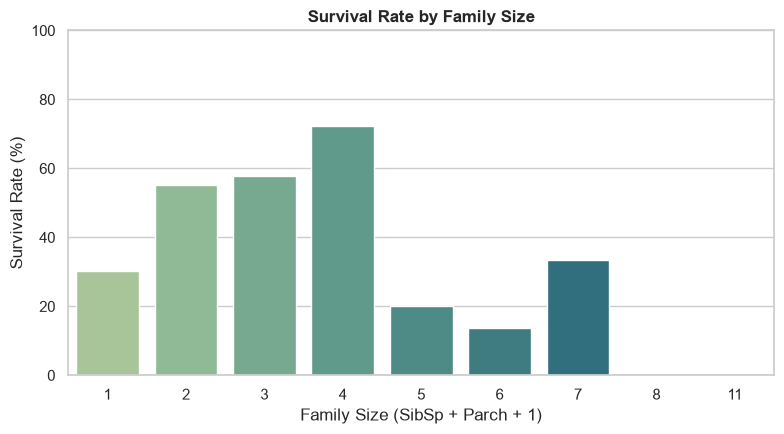

In [11]:
fam_surv = df.groupby('FamilySize')['Survived'].mean() * 100
print(fam_surv.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=fam_surv.index, y=fam_surv.values, hue=fam_surv.index,
            palette='crest', legend=False, ax=ax)
ax.set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
ax.set_xlabel('Family Size (SibSp + Parch + 1)')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('outputs/06_survival_by_familysize.png', bbox_inches='tight')
plt.show()


### 2.7 Correlation heatmap of numeric features

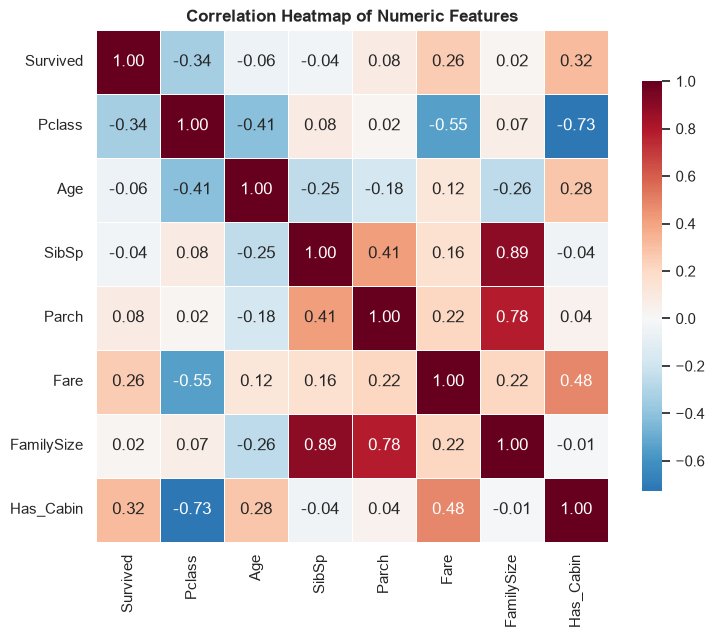

Has_Cabin     0.317
Fare          0.257
Parch         0.082
FamilySize    0.017
SibSp        -0.035
Age          -0.060
Pclass       -0.338
Name: Survived, dtype: float64


In [12]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Has_Cabin']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(corr['Survived'].drop('Survived').sort_values(ascending=False).round(3))


### 2.8 Grouped bar chart: Pclass x Sex x Survived

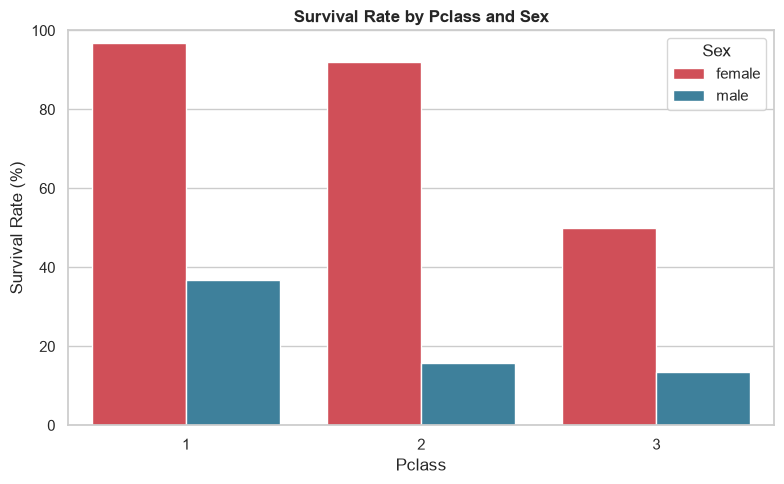

,Pclass,Sex,Survived
0,1,female,96.808511
1,1,male,36.885246
2,2,female,92.105263
3,2,male,15.740741
4,3,female,50.000000
5,3,male,13.544669


In [13]:
grp = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
grp['Survived'] = grp['Survived'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=grp, x='Pclass', y='Survived', hue='Sex',
            palette=[PALETTE["accent"], PALETTE["main"]], ax=ax)
ax.set_title('Survival Rate by Pclass and Sex', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Pclass')
ax.set_ylim(0, 100)
ax.legend(title='Sex')
plt.tight_layout()
plt.savefig('outputs/08_pclass_sex_survival.png', bbox_inches='tight')
plt.show()

grp


## 3. Key Insights

Based on the cleaned data and the charts above, six findings stand out:

1. **Sex was the single strongest predictor of survival.** Women survived at **74.2%**
   versus **18.9%** for men — a gap of roughly 55
   percentage points, consistent with a "women first" evacuation policy.

2. **Passenger class strongly shaped survival odds.** 1st class passengers survived at
   **63.0%**, compared to **47.3%** for 2nd class and
   only **24.2%** for 3rd class — survival roughly tracked cabin location and
   proximity to lifeboats.

3. **Class and sex compounded each other.** 1st-class women survived at **96.8%**, but 3rd-class men
   survived at just **13.5%** — nearly an 80-point gap between the safest and most at-risk groups
   (96.8% vs 13.5%).

4. **Fare correlates with survival mainly as a proxy for class.** Survivors paid a median fare of
   **$26.00** versus **$10.50** for non-survivors, and Fare
   correlates with Survived at **r = 0.26**. The distribution is right-skewed
   with **116 outlier fares** above $65.63 (up to $512.33),
   reflecting a small number of very expensive 1st-class tickets.

5. **Small families fared better than solo travelers or very large families.** Passengers traveling alone
   (FamilySize = 1) survived at only **30.4%**, while the best-performing group,
   FamilySize = 4, survived at **72.4%**. Very large families
   (7-11 members) had sharply lower survival, likely reflecting the difficulty of keeping a large group
   together during evacuation.

6. **Having a recorded cabin was associated with higher survival.** `Has_Cabin` correlates with `Survived`
   at **r = 0.32**, the second-strongest numeric correlation after
   `Pclass` (**r = -0.34**), again pointing to cabin location/class as a key
   survival factor rather than age (`r = -0.06`) or family size
   (`r = 0.02`), which showed weak linear relationships with survival.

**Overall survival rate across all 891 passengers: 38.38%.**
